# Exploratory Data Analysis: Freight Cost & Invoice Risk

## 1. Data Overview

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

conn = sqlite3.connect('data/inventory.db')
df = pd.read_sql("SELECT * FROM vendor_invoice", conn)
conn.close()

df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [5]:
print(df.shape)
print(df.info())

(5543, 10)
<class 'pandas.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   str    
 2   InvoiceDate   5543 non-null   str    
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   str    
 5   PayDate       5543 non-null   str    
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 433.2 KB
None


Every column is fully populated except Approval (5,169 missing out of 5,543)

In [4]:
df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000


Huge spread in Quantity, Dollars, Freight
1.Dollars: median ~$4,765, but mean ~$58,073 — the mean is 12x higher than the median
2.Freight: median $24.73, but mean $295.95 — 12x higher too
3.Quantity: median 423, but mean 6,058 — 14x higher

This is a classic sign of right-skewed data — a small number of huge orders are dragging the average way up, while most invoices are actually quite small. We should visualize this to see it clearly.

In [3]:
df.isnull().sum()

VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

Let's add visualization cells.

## 2. Distribution Analysis

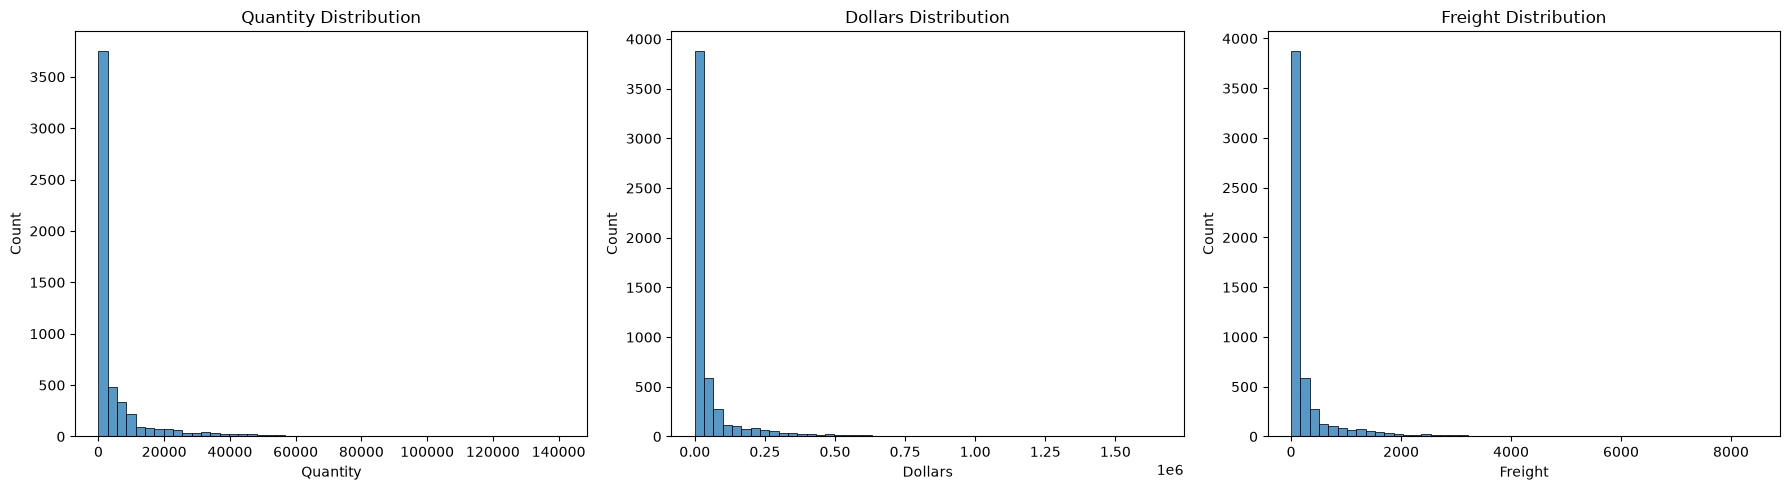

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Quantity'], bins=50, ax=axes[0])
axes[0].set_title('Quantity Distribution')

sns.histplot(df['Dollars'], bins=50, ax=axes[1])
axes[1].set_title('Dollars Distribution')

sns.histplot(df['Freight'], bins=50, ax=axes[2])
axes[2].set_title('Freight Distribution')

plt.tight_layout()
plt.show()

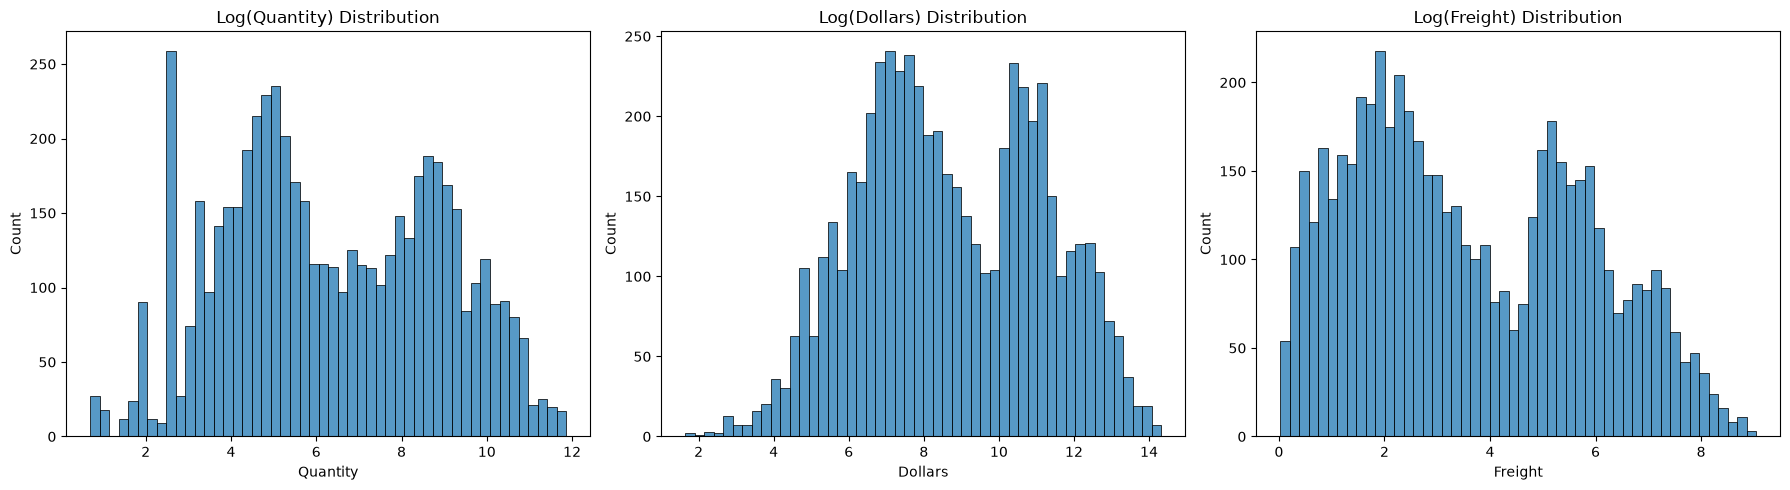

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(np.log1p(df['Quantity']), bins=50, ax=axes[0])
axes[0].set_title('Log(Quantity) Distribution')

sns.histplot(np.log1p(df['Dollars']), bins=50, ax=axes[1])
axes[1].set_title('Log(Dollars) Distribution')

sns.histplot(np.log1p(df['Freight']), bins=50, ax=axes[2])
axes[2].set_title('Log(Freight) Distribution')

plt.tight_layout()
plt.show()

After log-transforming, they look roughly normal :- Meaning the underlying pattern is more like "multiplicative" growth (e.g., doubling) rather than "additive" growth.


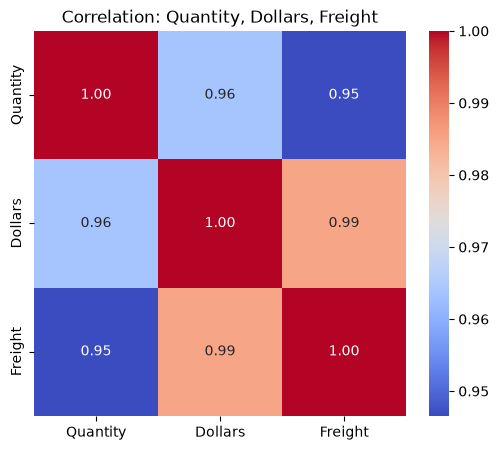

In [8]:
numeric_df = df[['Quantity', 'Dollars', 'Freight']].copy()
corr = numeric_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Quantity, Dollars, Freight')
plt.show()

## 3. Relationship Between Freight and Order Value

 Does Freight scale with order size? (scatter plot)

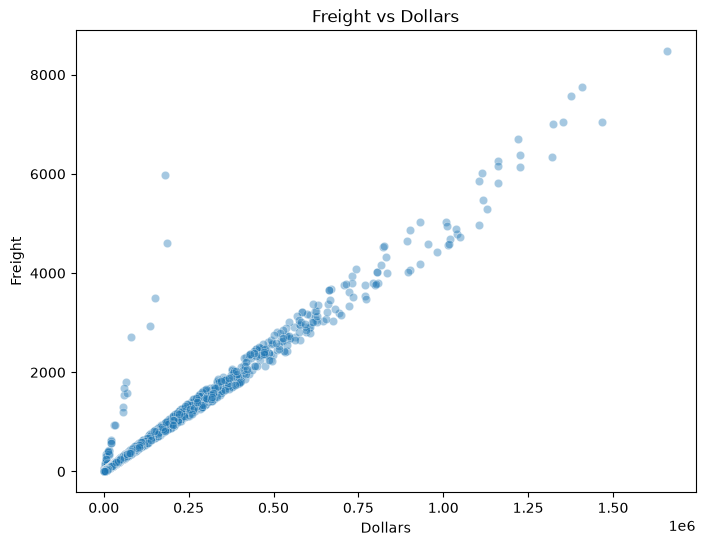

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Dollars', y='Freight', alpha=0.4)
plt.title('Freight vs Dollars')
plt.show()

Freight cost shows a strong, near-linear relationship with the total order value (Dollars). This suggests freight is likely calculated as a percentage or rate of order value, rather than being independently determined. 
A small number of invoices deviate from this pattern (e.g., unusually high freight relative to order value) — these could represent special shipping circumstances (rush orders, special handling, or distant vendors) and are worth flagging as potential outliers or risk indicators.

## Same, but log-scaled (to see the relationship more clearly)

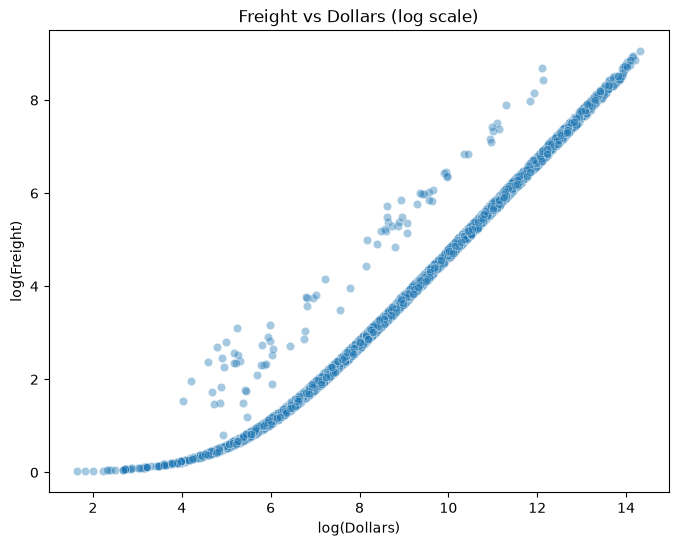

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=np.log1p(df['Dollars']), y=np.log1p(df['Freight']), alpha=0.4)
plt.xlabel('log(Dollars)')
plt.ylabel('log(Freight)')
plt.title('Freight vs Dollars (log scale)')
plt.show()

On a log scale, the linear relationship between Dollars and Freight holds consistently across both small and large orders, confirming this isn't just a large-order phenomenon. 
This strongly supports using Dollars (or its log transform) as a primary predictive feature for Freight in the regression model. The slight fanning-out at the lower end (small orders) suggests freight pricing may have a minimum baseline cost that adds proportionally more variance for very small orders.

Q. Which vendors have the most invoices / highest average freight?

In [11]:
vendor_summary = df.groupby('VendorName').agg(
    num_invoices=('Freight', 'count'),
    avg_freight=('Freight', 'mean'),
    avg_dollars=('Dollars', 'mean')
).sort_values('avg_freight', ascending=False)

vendor_summary.head(10)

,num_invoices,avg_freight,avg_dollars
VendorName,,,
DIAGEO NORTH AMERICA INC,55,4673.310364,926541.760909
MARTIGNETTI COMPANIES,55,2631.271273,505844.980182
JIM BEAM BRANDS COMPANY,55,2252.381273,440057.291818
PERNOD RICARD USA,55,2250.549455,438619.846545
BACARDI USA INC,55,1623.386727,320443.249455
CONSTELLATION BRANDS INC,55,1445.981636,283162.143636
BROWN-FORMAN CORP,55,1247.303273,245989.692364
ULTRA BEVERAGE COMPANY LLP,55,1237.358182,240192.980545
E & J GALLO WINERY,55,1126.671091,223447.419818


ANS:- The top vendors by average freight cost are large, well-known beverage distributors                                  
    1.Diageo,                                                                                                      
    2.Bacardi,                                                                                                       
    3.Jim Beam,                                                                                                       
    4.Pernod Ricard,                                                                                                      
    each consistently appearing with exactly 55 invoices in the dataset — suggesting these are regular, high-volume suppliers with a standardized invoicing cadence.

## 5. Feature Engineering: Timing Features

In [12]:
df['PODate'] = pd.to_datetime(df['PODate'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['PayDate'] = pd.to_datetime(df['PayDate'])

df['days_po_to_invoice'] = (df['InvoiceDate'] - df['PODate']).dt.days
df['days_invoice_to_pay'] = (df['PayDate'] - df['InvoiceDate']).dt.days
df['days_po_to_pay'] = (df['PayDate'] - df['PODate']).dt.days

df[['days_po_to_invoice', 'days_invoice_to_pay', 'days_po_to_pay']].describe()

,days_po_to_invoice,days_invoice_to_pay,days_po_to_pay
count,5543.000000,5543.000000,5543.000000
mean,16.424499,35.468519,51.893018
std,3.127282,5.842178,5.511373
min,9.000000,23.000000,40.000000
25%,14.000000,31.000000,47.000000
50%,16.000000,35.000000,52.000000
75%,19.000000,40.000000,56.000000
max,23.000000,48.000000,63.000000


All three timing features show relatively narrow, consistent ranges (e.g., days_po_to_invoice ranges only from 9–23 days), suggesting the company follows fairly standardized internal processing timelines rather than highly variable, ad-hoc scheduling. 

## 6. Defining Invoice Risk — First Attempt

In [13]:
high_freight = df['Freight'] > df['Freight'].quantile(0.75)
late_payment = df['days_invoice_to_pay'] > df['days_invoice_to_pay'].quantile(0.75)
df['is_risky'] = ((high_freight) | (late_payment)).astype(int)

# How does risk relate to vendor?
risk_by_vendor = df.groupby('VendorName')['is_risky'].mean().sort_values(ascending=False)
risk_by_vendor.head(10)

VendorName
AAPER ALCOHOL & CHEMICAL CO    1.000000
E & J GALLO WINERY             1.000000
ULTRA BEVERAGE COMPANY LLP     1.000000
LAUREATE IMPORTS CO            1.000000
M S WALKER INC                 1.000000
MOET HENNESSY USA INC          1.000000
DIAGEO NORTH AMERICA INC       0.981818
WILLIAM GRANT & SONS INC       0.981818
JIM BEAM BRANDS COMPANY        0.981818
BACARDI USA INC                0.981818
Name: is_risky, dtype: float64

## 7. Refining the Risk Label — Vendor-Relative Threshold

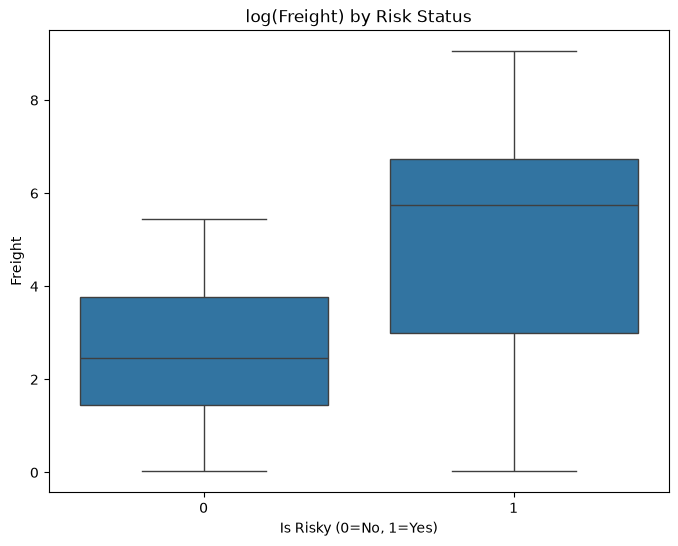

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='is_risky', y=np.log1p(df['Freight']))
plt.title('log(Freight) by Risk Status')
plt.xlabel('Is Risky (0=No, 1=Yes)')
plt.show()

In [15]:
# Calculate each vendor's OWN 75th percentile freight cost
vendor_freight_threshold = df.groupby('VendorName')['Freight'].transform(lambda x: x.quantile(0.75))

# An invoice is "high freight" only if it's unusually high FOR THAT VENDOR specifically
high_freight_relative = df['Freight'] > vendor_freight_threshold

print(high_freight_relative.value_counts())

Freight
False    4134
True     1409
Name: count, dtype: int64


## 8. Key Takeaways

In [ ]:
# Calculate each vendor's OWN 75th percentile freight cost
vendor_freight_threshold = df.groupby('VendorName')['Freight'].transform(lambda x: x.quantile(0.75))

# An invoice is "high freight" only if it's unusually high FOR THAT VENDOR specifically
high_freight_relative = df['Freight'] > vendor_freight_threshold

print(high_freight_relative.value_counts())

Freight
False    4134
True     1409
Name: count, dtype: int64


Rebuild is_risky using the vendor-relative threshold

In [16]:
late_payment = df['days_invoice_to_pay'] > df['days_invoice_to_pay'].quantile(0.75)

df['is_risky_v2'] = ((high_freight_relative) | (late_payment)).astype(int)

print(df['is_risky_v2'].value_counts())
print('Risk rate:', df['is_risky_v2'].mean())

is_risky_v2
0    3186
1    2357
Name: count, dtype: int64
Risk rate: 0.42522099945877684


Cell 15 — Re-check vendor risk rates with the fixed definition

In [17]:
risk_by_vendor_v2 = df.groupby('VendorName')['is_risky_v2'].mean().sort_values(ascending=False)
risk_by_vendor_v2.head(10)

VendorName
AAPER ALCOHOL & CHEMICAL CO    1.000000
LAUREATE IMPORTS CO            1.000000
UNCORKED                       0.714286
BLACK COVE BEVERAGES           0.625000
GILMANTON WINERY & VINEYARD    0.625000
MILTONS DISTRIBUTING CO        0.600000
Dunn Wine Brokers              0.560000
MARTIGNETTI COMPANIES          0.555556
VINEDREA WINES LLC             0.550000
SEA HAGG DISTILLERY LLC        0.518519
Name: is_risky_v2, dtype: float64

Risk Label Refinement: The initial composite risk definition (global top-25% Freight threshold) was found to disproportionately flag large, high-volume vendors (e.g., Diageo, Bacardi) as "risky" simply due to their naturally larger order sizes — not genuinely anomalous behavior. This was corrected by computing vendor-relative Freight thresholds (each vendor's own 75th percentile), so an invoice is now flagged only if it's unusually expensive for that specific vendor. This refinement shifted the top "risky" vendors away from large established companies toward smaller vendors with more variable invoicing patterns, while keeping the overall risk rate stable (41.4% → 42.5%), confirming the fix improved label quality without distorting class balance.

## Key EDA Takeaways

- Freight ≈ Dollars (corr. 0.985) — order value is the dominant driver of freight cost.
- Quantity & Dollars are heavily right-skewed; log-transform fixes this for scale-sensitive models like SVM.
- Big vendors ≠ risky vendors — large freight values were just a side-effect of large order sizes.
- First risk definition (global top-25%) was biased toward big vendors — fixed using **vendor-relative** thresholds instead.
- Final risk label = vendor-relative high freight **OR** slow payment — balanced at ~43% risky.
- Payment timing windows are tight and consistent (23–48 days invoice-to-pay), hinting at standardized internal processes.